# 🔍 CholecSeg8k Label Analysis - FIXED for Actual Structure

**Dataset Structure Discovered:**
```
cholecseg8k_raw/
├── video01/
│   ├── video01_00080/          # Temporal segment
│   │   ├── frame_87_endo.png                      # Original image
│   │   ├── frame_87_endo_mask.png                 # Mask
│   │   ├── frame_87_endo_watershed_mask.png       # Watershed mask (WHAT WE NEED)
│   │   ├── frame_87_endo_color_mask.png           # Color visualization
│   │   └── ...
│   ├── video01_00160/
│   └── ...
└── video02/
```

In [1]:
# Cell 1: Imports
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter
from tqdm import tqdm
import pandas as pd
import json

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Cell 2: Setup Paths
CHOLECSEG_DIR = Path("cholecseg8k_raw")
OUTPUT_DIR = Path("label_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset directory: {CHOLECSEG_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Dataset exists: {CHOLECSEG_DIR.exists()}")

# Find all video directories
video_dirs = sorted([d for d in CHOLECSEG_DIR.iterdir() if d.is_dir() and 'video' in d.name])
print(f"\nFound {len(video_dirs)} videos:")
for vid in video_dirs[:5]:
    print(f"  - {vid.name}")
if len(video_dirs) > 5:
    print(f"  ... and {len(video_dirs) - 5} more")

Dataset directory: cholecseg8k_raw
Output directory: label_analysis
Dataset exists: True

Found 17 videos:
  - video01
  - video09
  - video12
  - video17
  - video18
  ... and 12 more


In [3]:
# Cell 3: Understand File Naming Convention
print("Analyzing file naming convention...\n")

# Get first video's first segment
first_video = video_dirs[0]
segments = sorted([d for d in first_video.iterdir() if d.is_dir()])
first_segment = segments[0]

print(f"Sample segment: {first_segment.name}")
print(f"\nFiles in this segment:")

# Get all files
all_files = list(first_segment.glob("*.png"))
print(f"Total files: {len(all_files)}")

# Categorize by suffix
file_types = defaultdict(list)
for f in all_files:
    if '_endo.png' in f.name and 'mask' not in f.name:
        file_types['original_images'].append(f.name)
    elif '_endo_watershed_mask.png' in f.name:
        file_types['watershed_masks'].append(f.name)
    elif '_endo_color_mask.png' in f.name:
        file_types['color_masks'].append(f.name)
    elif '_endo_mask.png' in f.name:
        file_types['binary_masks'].append(f.name)

print("\nFile type breakdown:")
for ftype, files in file_types.items():
    print(f"  {ftype:20s}: {len(files):3d} files")
    if len(files) > 0:
        print(f"      Example: {files[0]}")

print("\n✅ We need: *_endo_watershed_mask.png files")

Analyzing file naming convention...

Sample segment: video01_00080

Files in this segment:
Total files: 320

File type breakdown:
  original_images     :  80 files
      Example: frame_87_endo.png
  binary_masks        :  80 files
      Example: frame_113_endo_mask.png
  color_masks         :  80 files
      Example: frame_155_endo_color_mask.png
  watershed_masks     :  80 files
      Example: frame_117_endo_watershed_mask.png

✅ We need: *_endo_watershed_mask.png files


Loading sample watershed mask...

Sample file: frame_117_endo_watershed_mask.png
Shape: (480, 854)
Dtype: uint8
Min value: 12
Max value: 255

Unique values in this mask (6 total):
  [ 12  13  21  22  50 255]


ValueError: operands could not be broadcast together with shapes (50,) (52,) (50,) 

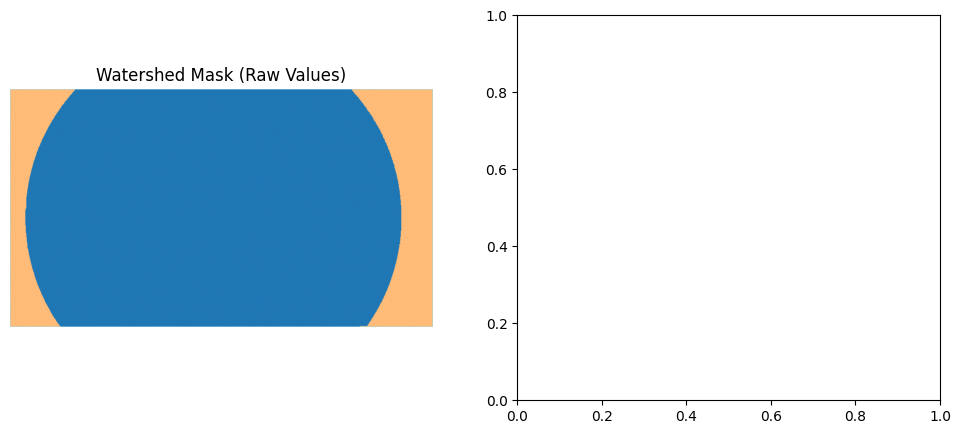

In [4]:
# Cell 4: Load Sample Watershed Mask
print("Loading sample watershed mask...\n")

# Find a watershed mask file
watershed_files = list(first_segment.glob("*_endo_watershed_mask.png"))

if len(watershed_files) > 0:
    sample_mask_path = watershed_files[0]
    sample_mask = cv2.imread(str(sample_mask_path), cv2.IMREAD_GRAYSCALE)
    
    print(f"Sample file: {sample_mask_path.name}")
    print(f"Shape: {sample_mask.shape}")
    print(f"Dtype: {sample_mask.dtype}")
    print(f"Min value: {sample_mask.min()}")
    print(f"Max value: {sample_mask.max()}")
    
    unique_values = np.unique(sample_mask)
    print(f"\nUnique values in this mask ({len(unique_values)} total):")
    print(f"  {unique_values}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original mask
    axes[0].imshow(sample_mask, cmap='tab20')
    axes[0].set_title('Watershed Mask (Raw Values)')
    axes[0].axis('off')
    
    # Histogram of values
    axes[1].hist(sample_mask.flatten(), bins=50, edgecolor='black')
    axes[1].set_xlabel('Pixel Value (Class ID)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Class IDs')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_mask_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Sample visualization saved")
else:
    print("❌ No watershed mask files found!")

In [12]:
# Cell: Generate Comprehensive Visualizations for ALL Labels
print("\n" + "="*80)
print("GENERATING COMPREHENSIVE VISUALIZATIONS FOR ALL LABELS")
print("="*80)
print("\nThis will create 2+ sample images for EVERY label found in the dataset\n")

def find_multiple_samples_with_class(video_dirs, target_class, num_samples=3, max_search=200):
    """Find multiple sample frames that contain the target class"""
    samples = []
    
    for video_dir in video_dirs:
        if len(samples) >= num_samples:
            break
            
        segments = [d for d in video_dir.iterdir() if d.is_dir()]
        
        for segment_dir in segments:
            if len(samples) >= num_samples:
                break
                
            # Get watershed masks
            mask_files = list(segment_dir.glob("*_endo_watershed_mask.png"))
            np.random.shuffle(mask_files)
            
            for mask_path in mask_files[:max_search]:
                if len(samples) >= num_samples:
                    break
                    
                mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                if mask is None:
                    continue
                
                # Check if this class exists with reasonable size
                if target_class in np.unique(mask):
                    class_pixels = np.sum(mask == target_class)
                    
                    # Only use if class has at least 100 pixels (visible)
                    if class_pixels < 100:
                        continue
                    
                    # Find corresponding original image
                    image_name = mask_path.name.replace('_endo_watershed_mask.png', '_endo.png')
                    image_path = segment_dir / image_name
                    
                    if image_path.exists():
                        image = cv2.imread(str(image_path))
                        if image is not None:
                            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                            samples.append({
                                'image': image,
                                'mask': mask,
                                'path': str(mask_path),
                                'pixels': class_pixels
                            })
    
    return samples

# Create output directory for all labels
all_labels_viz_dir = OUTPUT_DIR / "all_labels_visualizations"
all_labels_viz_dir.mkdir(exist_ok=True)

print(f"Output directory: {all_labels_viz_dir}\n")

# Process each label
for label_idx, label in enumerate(all_labels):
    print(f"Processing Label {label:3d} ({label_idx+1}/{len(all_labels)})...", end=" ")
    
    # Get label name if known
    label_name = KNOWN_CLASSES.get(label, "Unknown")
    
    # Find samples
    samples = find_multiple_samples_with_class(video_dirs, label, num_samples=3, max_search=300)
    
    if len(samples) == 0:
        print(f"No samples found (skipping)")
        continue
    
    # Determine grid size based on number of samples
    num_samples = len(samples)
    
    # Create figure: each sample gets 2 columns (original + overlay)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    # Handle case of single sample
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, sample in enumerate(samples):
        image = sample['image']
        mask = sample['mask']
        pixels = sample['pixels']
        
        # Original image
        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title(f'Original Frame (Sample {idx+1})')
        axes[idx, 0].axis('off')
        
        # Binary mask for this class
        class_mask = (mask == label).astype(np.uint8) * 255
        axes[idx, 1].imshow(class_mask, cmap='hot', vmin=0, vmax=255)
        axes[idx, 1].set_title(f'Class {label} Mask\n({pixels:,} pixels)')
        axes[idx, 1].axis('off')
        
        # Overlay
        overlay = image.copy()
        overlay[mask == label] = overlay[mask == label] * 0.5 + np.array([255, 0, 0]) * 0.5
        axes[idx, 2].imshow(overlay.astype(np.uint8))
        axes[idx, 2].set_title(f'Overlay')
        axes[idx, 2].axis('off')
    
    # Overall title with statistics
    pixel_count = label_counts[label]
    video_count = len(video_label_map[label])
    percentage = 100 * pixel_count / sum(label_counts.values())
    
    fig.suptitle(
        f'Label {label}: {label_name}\n'
        f'Total: {pixel_count:,} pixels ({percentage:.3f}%) | Found in {video_count}/{len(video_dirs)} videos | {num_samples} samples shown',
        fontsize=14, fontweight='bold'
    )
    
    plt.tight_layout()
    
    # Save with padded label number for sorting
    output_path = all_labels_viz_dir / f"label_{label:03d}_{label_name.lower().replace(' ', '_')}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved {num_samples} samples")

print("\n" + "="*80)
print("✅ COMPREHENSIVE VISUALIZATION COMPLETE!")
print("="*80)
print(f"\nGenerated visualizations for {len(list(all_labels_viz_dir.glob('*.png')))} labels")
print(f"Location: {all_labels_viz_dir}")
print("\nEach file shows:")
print("  • 2-3 different sample frames containing that label")
print("  • Original frame | Binary mask | Overlay")
print("  • Pixel statistics and frequency information")
print("\nFiles are named: label_XXX_name.png (sorted numerically)")


GENERATING COMPREHENSIVE VISUALIZATIONS FOR ALL LABELS

This will create 2+ sample images for EVERY label found in the dataset

Output directory: label_analysis/all_labels_visualizations

Processing Label   0 (1/15)... No samples found (skipping)
Processing Label   5 (2/15)... ✓ Saved 3 samples
Processing Label  11 (3/15)... ✓ Saved 3 samples
Processing Label  12 (4/15)... ✓ Saved 3 samples
Processing Label  13 (5/15)... ✓ Saved 3 samples
Processing Label  21 (6/15)... ✓ Saved 3 samples
Processing Label  22 (7/15)... ✓ Saved 3 samples
Processing Label  23 (8/15)... ✓ Saved 3 samples
Processing Label  24 (9/15)... ✓ Saved 3 samples
Processing Label  25 (10/15)... ✓ Saved 3 samples
Processing Label  31 (11/15)... ✓ Saved 3 samples
Processing Label  32 (12/15)... ✓ Saved 3 samples
Processing Label  33 (13/15)... ✓ Saved 3 samples
Processing Label  50 (14/15)... ✓ Saved 3 samples
Processing Label 255 (15/15)... ✓ Saved 3 samples

✅ COMPREHENSIVE VISUALIZATION COMPLETE!

Generated visualiz

In [5]:
# Cell 5: Scan All Watershed Masks for Unique Labels
print("Scanning all watershed masks across all videos...\n")
print("This will take a few minutes...\n")

all_labels = set()
label_counts = Counter()
video_label_map = defaultdict(set)

total_masks_scanned = 0

for video_dir in tqdm(video_dirs, desc="Processing videos"):
    # Get all segments in this video
    segments = sorted([d for d in video_dir.iterdir() if d.is_dir()])
    
    for segment_dir in segments:
        # Find all watershed masks in this segment
        watershed_masks = list(segment_dir.glob("*_endo_watershed_mask.png"))
        
        # Sample masks from this segment (not all, to save time)
        sample_size = min(10, len(watershed_masks))  # 10 masks per segment
        if len(watershed_masks) > 0:
            sampled_masks = np.random.choice(watershed_masks, sample_size, replace=False)
        else:
            continue
        
        for mask_path in sampled_masks:
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            if mask is None:
                continue
            
            # Get unique labels
            unique_labels = np.unique(mask)
            all_labels.update(unique_labels)
            
            # Count pixels
            for label in unique_labels:
                label_counts[label] += np.sum(mask == label)
                video_label_map[label].add(video_dir.name)
            
            total_masks_scanned += 1

all_labels = sorted(all_labels)

print(f"\n✅ Scan complete!")
print(f"   Total masks scanned: {total_masks_scanned:,}")
print(f"   Total unique labels found: {len(all_labels)}")
print(f"   Label range: {min(all_labels)} to {max(all_labels)}")
print(f"\n   All labels: {all_labels}")

Scanning all watershed masks across all videos...

This will take a few minutes...



Processing videos: 100%|█████████████████████████████████████████████████████████████████████████████| 17/17 [00:05<00:00,  3.03it/s]


✅ Scan complete!
   Total masks scanned: 1,010
   Total unique labels found: 15
   Label range: 0 to 255

   All labels: [np.uint8(0), np.uint8(5), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(50), np.uint8(255)]


In [6]:
# Cell 6: Create Frequency Table
label_data = []
for label in all_labels:
    label_data.append({
        'Label': label,
        'Total Pixels': label_counts[label],
        'Videos': len(video_label_map[label]),
        'Percentage': 100 * label_counts[label] / sum(label_counts.values())
    })

df = pd.DataFrame(label_data)
df = df.sort_values('Total Pixels', ascending=False)

print("="*80)
print("LABEL FREQUENCY TABLE")
print("="*80)
print("\nTop 20 Most Frequent Labels:")
print(df.head(20).to_string(index=False))

df.to_csv(OUTPUT_DIR / "label_frequency_table.csv", index=False)
print(f"\n📊 Full table saved: {OUTPUT_DIR / 'label_frequency_table.csv'}")

LABEL FREQUENCY TABLE

Top 20 Most Frequent Labels:
 Label  Total Pixels  Videos  Percentage
    50     109763673      17   26.511735
    11      88960351      16   21.487011
    21      88645787      17   21.411033
    12      60864208      17   14.700818
    22      26405332      16    6.377804
    31       9810593      16    2.369599
    23       9338733       2    2.255628
    13       7786893      13    1.880805
    32       5613504       8    1.355856
   255       3070388      17    0.741605
    24       1771197       1    0.427806
     5       1754985       1    0.423890
    25        192550       2    0.046508
    33         40982       1    0.009899
     0            24       5    0.000006

📊 Full table saved: label_analysis/label_frequency_table.csv


In [7]:
# Cell 7: Known Class Mappings
print("\n" + "="*80)
print("KNOWN CLASS MAPPINGS")
print("="*80)

KNOWN_CLASSES = {
    0: "Background",
    11: "Abdominal Wall",
    12: "Liver",
    13: "Gastrointestinal Tract",
    14: "Fat",
    15: "Grasping Retractor",
    21: "Grasper (Instrument)",
    22: "Bipolar (Instrument)",
    23: "Hook (Instrument)",
    24: "Blood",
    25: "Scissors (Instrument)",
    26: "Clipper (Instrument)",
    27: "Irrigator (Instrument)",
    28: "Specimen Bag",
    31: "Suction Instrument",
    32: "Hepatic Vein",
    33: "Liver Ligament",
}

INSTRUMENT_CLASSES = {
    21: "Grasper",
    22: "Bipolar",
    23: "Hook",
    25: "Scissors",
    26: "Clipper",
    27: "Irrigator",
    28: "Specimen Bag",
    31: "Suction"
}

print("\n🔧 Known Surgical Instruments:")
print("-" * 80)
found_instruments = 0
for label in sorted(INSTRUMENT_CLASSES.keys()):
    if label in all_labels:
        status = "✓ FOUND"
        pixel_count = label_counts[label]
        video_count = len(video_label_map[label])
        percentage = 100 * pixel_count / sum(label_counts.values())
        print(f"  Class {label:2d}: {INSTRUMENT_CLASSES[label]:20s} - {status}")
        print(f"           Pixels: {pixel_count:,} ({percentage:.3f}%)")
        print(f"           Videos: {video_count}/{len(video_dirs)}")
        found_instruments += 1
    else:
        status = "✗ NOT FOUND"
        print(f"  Class {label:2d}: {INSTRUMENT_CLASSES[label]:20s} - {status}")

print(f"\nTotal instruments found: {found_instruments}/{len(INSTRUMENT_CLASSES)}")

print("\n🩸 Blood Class:")
print("-" * 80)
if 24 in all_labels:
    pixel_count = label_counts[24]
    video_count = len(video_label_map[24])
    percentage = 100 * pixel_count / sum(label_counts.values())
    print(f"  Class 24: Blood - ✓ FOUND")
    print(f"           Pixels: {pixel_count:,} ({percentage:.3f}%)")
    print(f"           Videos: {video_count}/{len(video_dirs)}")
else:
    print(f"  Class 24: Blood - ✗ NOT FOUND")

print("\n❓ Unknown Labels (not in documentation):")
print("-" * 80)
unknown_labels = [l for l in all_labels if l not in KNOWN_CLASSES]
if unknown_labels:
    print(f"Found {len(unknown_labels)} unknown labels:")
    for label in unknown_labels:
        pixel_count = label_counts[label]
        percentage = 100 * pixel_count / sum(label_counts.values())
        print(f"  Label {label:3d}: {pixel_count:,} pixels ({percentage:.3f}%)")
else:
    print("None - all labels are documented!")


KNOWN CLASS MAPPINGS

🔧 Known Surgical Instruments:
--------------------------------------------------------------------------------
  Class 21: Grasper              - ✓ FOUND
           Pixels: 88,645,787 (21.411%)
           Videos: 17/17
  Class 22: Bipolar              - ✓ FOUND
           Pixels: 26,405,332 (6.378%)
           Videos: 16/17
  Class 23: Hook                 - ✓ FOUND
           Pixels: 9,338,733 (2.256%)
           Videos: 2/17
  Class 25: Scissors             - ✓ FOUND
           Pixels: 192,550 (0.047%)
           Videos: 2/17
  Class 26: Clipper              - ✗ NOT FOUND
  Class 27: Irrigator            - ✗ NOT FOUND
  Class 28: Specimen Bag         - ✗ NOT FOUND
  Class 31: Suction              - ✓ FOUND
           Pixels: 9,810,593 (2.370%)
           Videos: 16/17

Total instruments found: 5/8

🩸 Blood Class:
--------------------------------------------------------------------------------
  Class 24: Blood - ✓ FOUND
           Pixels: 1,771,197 (0.428%)
   

In [8]:
# Cell 8: Visualize Each Instrument Class
print("\n" + "="*80)
print("GENERATING SAMPLE VISUALIZATIONS")
print("="*80)

def find_sample_with_class(video_dirs, target_class, max_search=50):
    """Find a sample frame that contains the target class"""
    for video_dir in video_dirs:
        segments = [d for d in video_dir.iterdir() if d.is_dir()]
        
        for segment_dir in segments:
            # Get watershed masks
            mask_files = list(segment_dir.glob("*_endo_watershed_mask.png"))
            np.random.shuffle(mask_files)
            
            for mask_path in mask_files[:max_search]:
                mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                if mask is None:
                    continue
                
                # Check if this class exists
                if target_class in np.unique(mask):
                    # Find corresponding original image
                    image_name = mask_path.name.replace('_endo_watershed_mask.png', '_endo.png')
                    image_path = segment_dir / image_name
                    
                    if image_path.exists():
                        image = cv2.imread(str(image_path))
                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                        return image, mask, str(mask_path)
    
    return None, None, None

print("\nSearching for sample frames with each instrument...\n")

for class_id, class_name in INSTRUMENT_CLASSES.items():
    if class_id not in all_labels:
        print(f"  ✗ {class_name} (Class {class_id}): Not in dataset")
        continue
    
    # Find sample
    image, mask, mask_path = find_sample_with_class(video_dirs, class_id, max_search=100)
    
    if image is None:
        print(f"  ✗ {class_name} (Class {class_id}): Could not find sample")
        continue
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Frame')
    axes[0].axis('off')
    
    # Class mask (binary)
    class_mask = (mask == class_id).astype(np.uint8) * 255
    axes[1].imshow(class_mask, cmap='hot')
    axes[1].set_title(f'{class_name} Mask (Class {class_id})')
    axes[1].axis('off')
    
    # Overlay
    overlay = image.copy()
    overlay[mask == class_id] = overlay[mask == class_id] * 0.5 + np.array([255, 0, 0]) * 0.5
    axes[2].imshow(overlay.astype(np.uint8))
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.suptitle(f'{class_name} (Class {class_id}) - Sample Visualization', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Save
    output_path = OUTPUT_DIR / f"class_{class_id:02d}_{class_name.lower()}_sample.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ {class_name} (Class {class_id}): Saved")

print("\n✅ Visualizations complete!")


GENERATING SAMPLE VISUALIZATIONS

Searching for sample frames with each instrument...

  ✓ Grasper (Class 21): Saved
  ✓ Bipolar (Class 22): Saved
  ✓ Hook (Class 23): Saved
  ✓ Scissors (Class 25): Saved
  ✗ Clipper (Class 26): Not in dataset
  ✗ Irrigator (Class 27): Not in dataset
  ✗ Specimen Bag (Class 28): Not in dataset
  ✓ Suction (Class 31): Saved

✅ Visualizations complete!


In [9]:
# Cell 9: Generate Blood Visualization
if 24 in all_labels:
    print("Generating blood (Class 24) reference visualization...\n")
    
    image, mask, mask_path = find_sample_with_class(video_dirs, 24, max_search=50)
    
    if image is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(image)
        axes[0].set_title('Original Frame')
        axes[0].axis('off')
        
        blood_mask = (mask == 24).astype(np.uint8) * 255
        axes[1].imshow(blood_mask, cmap='hot')
        axes[1].set_title('Blood Mask (Class 24)')
        axes[1].axis('off')
        
        overlay = image.copy()
        overlay[mask == 24] = overlay[mask == 24] * 0.5 + np.array([255, 0, 0]) * 0.5
        axes[2].imshow(overlay.astype(np.uint8))
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        plt.suptitle('Blood (Class 24) - Reference Visualization', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        output_path = OUTPUT_DIR / "class_24_blood_sample.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"  ✓ Blood visualization saved")

Generating blood (Class 24) reference visualization...

  ✓ Blood visualization saved


In [10]:
# Cell 10: Save Class Mapping
print("\n" + "="*80)
print("SAVING CLASS MAPPING")
print("="*80)

INSTRUMENT_MAPPING = {
    class_id: class_name 
    for class_id, class_name in INSTRUMENT_CLASSES.items() 
    if class_id in all_labels
}

if 24 in all_labels:
    INSTRUMENT_MAPPING[24] = "Blood"

print("\nFinal Class Mapping (to use in training):")
print("-" * 80)
for class_id, class_name in sorted(INSTRUMENT_MAPPING.items()):
    print(f"  {class_id}: {class_name}")

# Save as JSON
mapping_path = OUTPUT_DIR / "class_mapping.json"
with open(mapping_path, 'w') as f:
    json.dump(INSTRUMENT_MAPPING, f, indent=2)

print(f"\n💾 Class mapping saved: {mapping_path}")

# Save as Python dict
dict_path = OUTPUT_DIR / "class_mapping.py"
with open(dict_path, 'w') as f:
    f.write("# CholecSeg8k Class Mapping - Auto-generated\n\n")
    f.write("CLASS_MAPPING = {\n")
    for class_id, class_name in sorted(INSTRUMENT_MAPPING.items()):
        f.write(f"    {class_id}: '{class_name}',\n")
    f.write("}\n\n")
    f.write("# Instrument classes only (excluding blood)\n")
    f.write("INSTRUMENT_CLASSES = {\n")
    for class_id, class_name in sorted(INSTRUMENT_MAPPING.items()):
        if class_id != 24:
            f.write(f"    {class_id}: '{class_name}',\n")
    f.write("}\n")

print(f"💾 Python dict saved: {dict_path}")


SAVING CLASS MAPPING

Final Class Mapping (to use in training):
--------------------------------------------------------------------------------
  21: Grasper
  22: Bipolar
  23: Hook
  24: Blood
  25: Scissors
  31: Suction

💾 Class mapping saved: label_analysis/class_mapping.json
💾 Python dict saved: label_analysis/class_mapping.py


In [11]:
# Cell 11: Final Summary
print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)

print("\n📊 Summary Statistics:")
print(f"  • Total masks scanned: {total_masks_scanned:,}")
print(f"  • Total unique labels: {len(all_labels)}")
print(f"  • Surgical instruments found: {len([c for c in INSTRUMENT_CLASSES.keys() if c in all_labels])}/{len(INSTRUMENT_CLASSES)}")
print(f"  • Blood class (24): {'✓ Found' if 24 in all_labels else '✗ Not found'}")

print("\n📁 Generated Files:")
print(f"  1. {OUTPUT_DIR / 'label_frequency_table.csv'}")
print(f"  2. {OUTPUT_DIR / 'class_mapping.json'}")
print(f"  3. {OUTPUT_DIR / 'class_mapping.py'}")
print(f"  4. Sample visualizations: {len(list(OUTPUT_DIR.glob('class_*.png')))} images")

print("\n🎯 Next Steps:")
print("  1. Review sample visualizations in label_analysis/ directory")
print("  2. Verify instrument classes match your expectations")
print("  3. Proceed to: 03_instrument_segmentation.ipynb")
print("  4. Use class_mapping.json for multi-class UNet training")

print("\n" + "="*80)


✅ ANALYSIS COMPLETE!

📊 Summary Statistics:
  • Total masks scanned: 1,010
  • Total unique labels: 15
  • Surgical instruments found: 5/8
  • Blood class (24): ✓ Found

📁 Generated Files:
  1. label_analysis/label_frequency_table.csv
  2. label_analysis/class_mapping.json
  3. label_analysis/class_mapping.py
  4. Sample visualizations: 6 images

🎯 Next Steps:
  1. Review sample visualizations in label_analysis/ directory
  2. Verify instrument classes match your expectations
  3. Proceed to: 03_instrument_segmentation.ipynb
  4. Use class_mapping.json for multi-class UNet training

